# Regression Metrics

In this notebook we learn to:

- Split data before evaluating, and explain why (train/test proportions, Andrew Ng's rule).
- Establish a baseline with `DummyRegressor`.
- Interpret and compare MSE, $R^2$, MAE, median AE, and MAPE.

We use the **Ames housing** dataset:

- Feature: `GrLivArea` — above-grade living area (sq ft).
- Target: `SalePrice` in **k$** (thousands of dollars).

In [1]:
from pathlib import Path

# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/linear_model.html#linear-regression
from sklearn.linear_model import LinearRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html
from sklearn.dummy import DummyRegressor

# https://scikit-learn.org/stable/modules/model_evaluation.html
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
)


In [2]:
# Path to the Ames housing dataset, relative to this notebook
data_path = Path("../datasets/house_prices.csv")

ames_housing = pd.read_csv(data_path)

feature_name = "GrLivArea"
target_name = "SalePrice"

# Keep feature as a 2-D DataFrame (sklearn expects a matrix, not a 1-D Series)
X = ames_housing[[feature_name]]

# Express prices in thousands of dollars for easier reading
y = ames_housing[target_name] / 1000

ames_housing[[feature_name, target_name]].head()


,GrLivArea,SalePrice
0,1710,208500
1,1262,181500
2,1786,223500
3,1717,140000
4,2198,250000


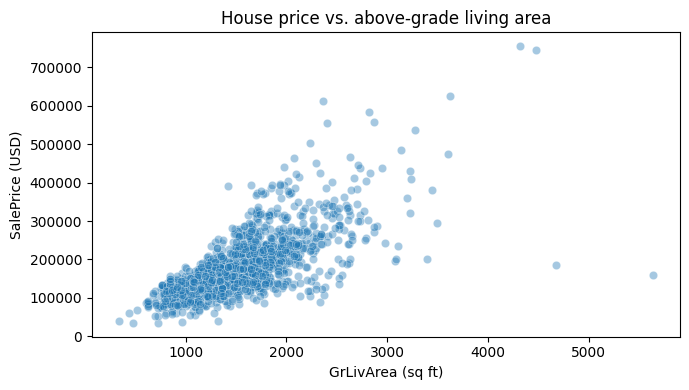

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    data=ames_housing,
    x=feature_name,
    y=target_name,
    ax=ax,
    alpha=0.4,
)
ax.set_title("House price vs. above-grade living area")
ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice (USD)")
plt.tight_layout()
plt.show()


## Why split first?

Before any preprocessing or modeling, hold out a **test set** that the model never sees during training.

- `train_test_split` randomly divides the dataset into two disjoint parts
- A model evaluated on the same data it was trained on gives an **optimistically biased** error rate
- A separate test set provides an **unbiased estimate** of generalization


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,  # feature matrix
    y,  # target vector
    test_size=0.2,  # hold out 20% for evaluation
    random_state=42,  # reproducible split
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of X_train: (1168, 1)
Shape of X_test: (292, 1)


### Train-test split proportions

![Dataset split into 80% training and 20% testing](../assets/train_test_split.svg)

- **Training set:** used purely to build the model
- **Testing set:** evaluates the model objectively on unseen rows


### Andrew Ng's rule of thumb

![Small datasets need a larger test fraction than massive datasets](../assets/train_test_proportions.svg)

- **Small datasets** (thousands of rows): use a larger test fraction (often 20–30%) so the test set is large enough to trust
- **Massive datasets** (millions of rows): even 1–2% can still be tens of thousands of test rows — plenty for a reliable score


## Mean squared error (MSE)

- **Definition:** average of squared differences between predictions and true values.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 \in [0, \infty)$$

- Penalizes **large errors** more strongly than small ones (the differences are squared).
- Has the **same scale as target squared** (k\$²), which makes it hard to interpret.
- It is the **loss** that `LinearRegression` minimizes on the training set, so it doubles as the training objective.

Raw MSE values (e.g. ~3078 on train, ~3419 on test) are hard to interpret without context — feel the friction of squared units and the lack of direct business meaning.

We still evaluate on a **test set**, since we care about **generalization**, not just training error.


In [5]:
regressor = LinearRegression()
regressor.fit(
    X=X_train,
    y=y_train,
)

y_pred_train = regressor.predict(X_train)

train_mse = mean_squared_error(
    y_true=y_train,
    y_pred=y_pred_train,
)
print(f"Mean squared error on the training set: {train_mse:.3f}")


Mean squared error on the training set: 3078.116


In [6]:
y_pred = regressor.predict(X_test)

test_mse = mean_squared_error(
    y_true=y_test,
    y_pred=y_pred,
)
print(f"Mean squared error on the testing set: {test_mse:.3f}")


Mean squared error on the testing set: 3418.946


## $R^2$: coefficient of determination

Raw MSE is hard to interpret (units are k$ squared). $R^2$ rescales MSE by the variance of the target:

$$R^2 = 1 - \frac{\text{MSE}}{\sigma_y^2} \in (-\infty, 1]$$

- Supplies a **dimensionless, relative** notion of performance — how much better the model is than always predicting the mean.
- **Interpretation:** proportion of target variance explained by the model.
- $R^2 = 1$: perfect predictions.
- $R^2 = 0$: same as always predicting the mean of the target.
- $R^2 < 0$: worse than predicting the mean (no lower bound).

This is the default score when you call `.score()` on a scikit-learn regressor.


In [7]:
r2_score = regressor.score(
    X=X_test,
    y=y_test,
)
print(f"R² score on the test set: {r2_score:.3f}")


R² score on the test set: 0.554


## Baseline: dummy regressor

Always compare against a simple baseline. A `DummyRegressor` with `strategy="mean"` always predicts the **mean** of the target on the training set.

- On the test set, the dummy model achieves $R^2 \approx 0$.
- Our linear regression should **beat** this baseline to be useful.


In [12]:
dummy_regressor = DummyRegressor(
    strategy="mean",  # always predict the training-set mean
)
dummy_regressor.fit(
    X=X_train,
    y=y_train,
)

dummy_r2 = dummy_regressor.score(
    X=X_test,
    y=y_test,
)
print(f"R² score for a dummy regressor predicting the mean: {dummy_r2:.3f}")


R² score for a dummy regressor predicting the mean: -0.001


## Limitations of $R^2$

$R^2$ gives insight into fit quality, but:

- **Cannot be compared across datasets** — different target variances imply different $R^2$ scales.
- **Not in original units** — stakeholders cannot read errors directly in k$.
- We often need **more interpretable metrics** for communication.


## Mean absolute error (MAE)

- **Definition:** average of absolute differences between predictions and true values.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right| \in [0, \infty)$$

- Same unit as the **target** (k$ here).
- More robust than MSE to **large outliers**, but still mean-based.
- Business stakeholders usually prefer MAE: easy to narrate as **"average absolute dollar error."**
- In this example, MAE ≈ 38 k$ ⇒ on average, predictions are off by ~38 k$.


In [13]:
mae = mean_absolute_error(
    y_true=y_test,
    y_pred=y_pred,
)
print(f"Mean absolute error: {mae:.3f} k$")


Mean absolute error: 38.341 k$


## Median absolute error

- **Definition:** median of absolute errors.

$$\text{Med AE} = \text{median}\left(\left| y_i - \hat{y}_i \right|\right) \in [0, \infty)$$

- Even more robust to **outliers** than MAE.
- Gives a sense of a **typical error** when a small fraction of cases are very bad.
- In this example, median AE ≈ 26 k$ ⇒ half of houses are predicted within ~26 k$.
- **Read MAE and median AE together:** if they are far apart, the error distribution is skewed with heavy tails (a few very bad predictions pulling the mean up).


In [14]:
median_ae = median_absolute_error(
    y_true=y_test,
    y_pred=y_pred,
)
print(f"Median absolute error: {median_ae:.3f} k$")


Median absolute error: 25.837 k$


## Mean absolute percentage error (MAPE)

- **Definition:** mean absolute error expressed as a percentage of the true value.

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \in [0, \infty)$$

- Example: a MAPE of 12% implies an average accuracy of ~88% in our predictions.
- People often want **"average % error"** for revenue, demand, or sales forecasts — a familiar KPI for stakeholders.

**The good**

- Compare performance across datasets with different scales.
- You can say, "I'm 5% off on sales for a small store and 5% off for a giant warehouse," even though the dollar amounts are vastly different.

**The gotchas**

- **Zero-division:** undefined or unstable when true values are near zero.
- **Asymmetry:** penalizes over-predictions more than under-predictions.


In [15]:
mape = mean_absolute_percentage_error(
    y_true=y_test,
    y_pred=y_pred,
)
print(f"Mean absolute percentage error: {mape * 100:.3f} %")


Mean absolute percentage error: 23.342 %


## Summary: regression metrics toolkit

- **MSE / $R^2$:** useful for comparing models on the **same** dataset.
- **MAE / median AE:** interpretable in original units; robust to outliers.
- **MAPE:** business-friendly and comparable across datasets (watch for zeros).

No single metric is universally best — the right choice depends on the domain, stakeholder needs, and model behavior.

| **Metric** | **Formula** | **Range** | **Utility** | **Limitations** |
| --- | --- | --- | --- | --- |
| **MSE** | $\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ | $[0, \infty)$ | Heavily penalizes large deviations; convenient for optimization. | Units are squared; sensitive to outliers. |
| **$R^2$** | $1 - \frac{\text{MSE}}{\sigma_y^2}$ | $(-\infty, 1]$ | Proportion of variance explained vs. predicting the mean. | Not in original units; not comparable across datasets. |
| **MAE** | $\frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$ | $[0, \infty)$ | Robust to outliers; same units as target. | Mean can be pulled by extreme errors. |
| **Median AE** | $\text{median}(\lvert y_i - \hat{y}_i \rvert)$ | $[0, \infty)$ | Highly robust; typical error when outliers exist. | Ignores error magnitude beyond the median. |
| **MAPE** | $\frac{1}{n} \sum_{i=1}^{n} \frac{\lvert y_i - \hat{y}_i \rvert}{\lvert y_i \rvert}$ | $[0, \infty)$ | Relative scale across datasets. | Undefined if $y_i = 0$; biased toward under-prediction. |
